In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import plotly.express as px
import seaborn as sns
import numpy as np
import simpy as sp
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.colors import qualitative

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression, HuberRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.inspection import permutation_importance
from tabulate import tabulate

##### Variables de climat à l'année


#### Data Loading and Format

In [5]:
from tabulate import tabulate

# Verify data loading and name format
df_yield = pd.read_csv("data\\barley_yield_from_1982.csv", delimiter=";")
df_yield = df_yield.drop(columns=['Unnamed: 0'])
table = pq.read_table("data\\climate_data_from_1982.parquet")
df_climate = table.to_pandas()

# Datetime for better plotting
df_climate['datetime'] = pd.to_datetime(df_climate['time'])
df_climate = df_climate.drop(columns=['year', 'code_dep', 'time'])
# Departement names to title case
df_climate.rename(columns={'nom_dep': 'department'}, inplace=True)
# Convert to degrees Celsius
df_climate.loc[df_climate['metric'] == 'near_surface_air_temperature', 'value'] = df_climate.loc[df_climate['metric'] == 'near_surface_air_temperature', 'value'] - 273.
df_climate.loc[df_climate['metric'] == 'daily_maximum_near_surface_air_temperature', 'value'] = df_climate.loc[df_climate['metric'] == 'daily_maximum_near_surface_air_temperature', 'value'] - 273.

# Add dummy month and day columns for df_yield
df_yield['month'] = 1 
df_yield['day'] = 1   
df_yield['datetime'] = pd.to_datetime(df_yield[['year', 'month', 'day']])
df_yield = df_yield.drop(columns=['month', 'day', 'year'])

TARGET_DEPARTMENTS = ['Isere', 'Cher', 'Somme', 'Haute-Garonne', 'Essonne']

#### Data Exploration


##### Climate Data

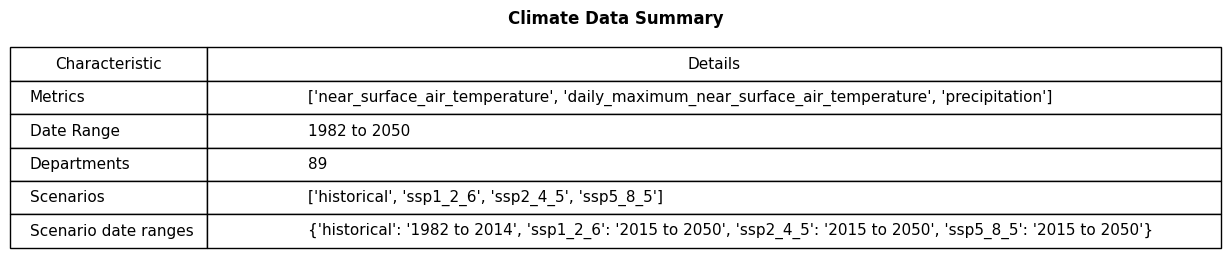

In [6]:
metrics = df_climate['metric'].unique().tolist()
mean_val = df_climate['value'].mean()
scenarios = df_climate['scenario'].unique().tolist()
date_ranges = {scenario: f"{df_climate[df_climate['scenario'] == scenario]['datetime'].min().year} to {df_climate[df_climate['scenario'] == scenario]['datetime'].max().year}" for scenario in scenarios}

summary_data = [
    ["Metrics", metrics],
    ["Date Range", f"{df_climate['datetime'].min().year} to {df_climate['datetime'].max().year}"],
    ["Departments", df_climate['department'].nunique()],
    ["Scenarios", scenarios],
    ["Scenario date ranges", date_ranges],
]


fig, ax = plt.subplots(figsize=(6, 3)) # Compact size
ax.axis('off')
table = ax.table(
    cellText=summary_data, 
    colLabels=["Characteristic", "Details"], 
    loc='center', 
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(summary_data[0]))))
table.scale(1, 2)

plt.title("Climate Data Summary", fontweight='bold')
plt.savefig("graph\\climate_data_summary.png", bbox_inches='tight', dpi=300)
plt.show()

##### Barley Yield

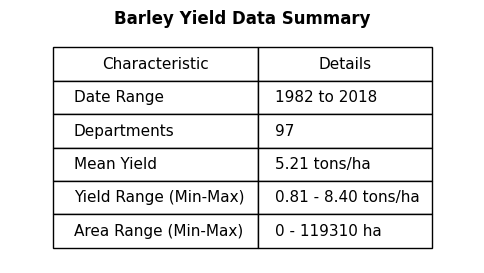

In [7]:
mean_val = df_yield['yield'].mean()
std_val = df_yield['yield'].std()  
min_val = df_yield['yield'].min()  
max_val = df_yield['yield'].max()  

summary_data = [
    ["Date Range", f"{df_yield['datetime'].min().year} to {df_yield['datetime'].max().year}"],
    ["Departments", df_yield['department'].nunique()],
    ["Mean Yield", f"{mean_val:.2f} tons/ha"],
    ["Yield Range (Min-Max)", f"{min_val:.2f} - {max_val:.2f} tons/ha"],
    ["Area Range (Min-Max)", f"{df_yield['area'].min():.0f} - {df_yield['area'].max():.0f} ha"]
]

fig, ax = plt.subplots(figsize=(6, 3)) # Compact size
ax.axis('off')
table = ax.table(
    cellText=summary_data, 
    colLabels=["Characteristic", "Details"], 
    loc='center', 
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(summary_data[0]))))
table.scale(1, 2)

plt.title("Barley Yield Data Summary", fontweight='bold')
plt.savefig("graph\\yield_data_summary.png", bbox_inches='tight', dpi=300)
plt.show()


##### Datasets comparison

In [8]:
# Unique departments in each dataset
departments_climate = set(df_climate['department'].unique())
departments_yield = set(df_yield['department'].unique())

# Comparison
unique_to_climate = departments_climate - departments_yield
unique_to_yield = departments_yield - departments_climate

# Display results
print(f"Departments unique to yield dataset: {unique_to_yield}")

# Discard data in departments unique to yield dataset
df_yield = df_yield[~df_yield['department'].isin(unique_to_yield)]

Departments unique to yield dataset: {'Paris', 'Hauts_de_Seine', 'Val_de_Marne', 'Seine_SeineOise', 'Seine_Saint_Denis', 'Val_d_Oise', 'Haute_Corse', 'Corse_du_Sud'}


#### Statistical Exploratory Analysis


##### Yield, Area, Production Distribution


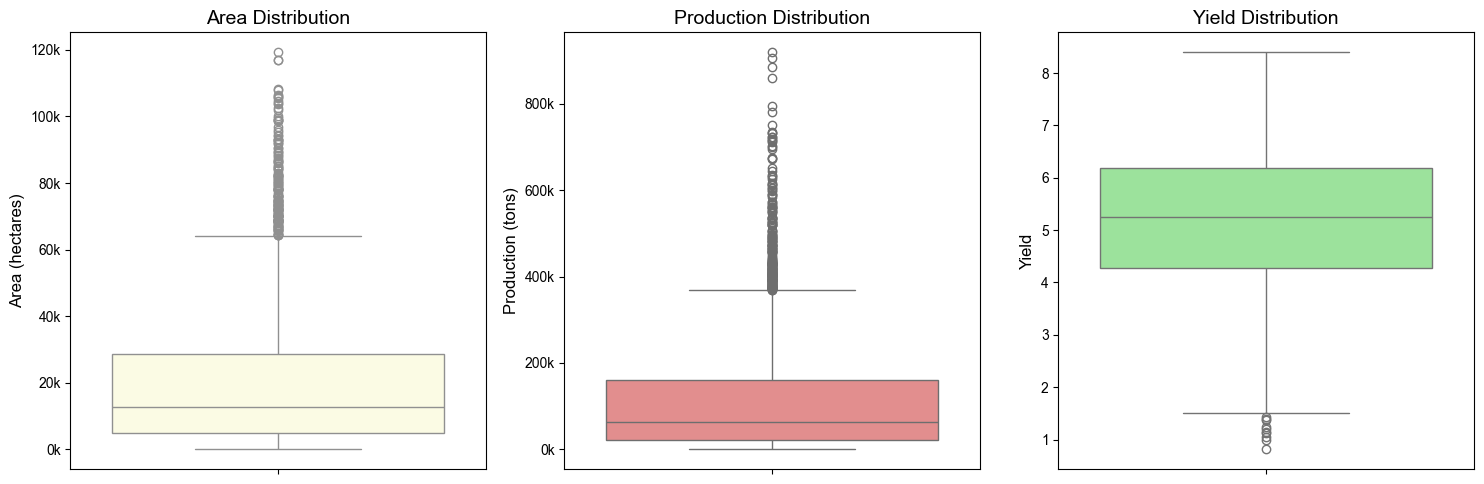

In [9]:
# Yield Data Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.set_theme(style="whitegrid")  # Set a clean theme
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})  # Update font settings

sns.boxplot(data=df_yield, y='area', ax=axes[0], color='lightyellow')
axes[0].set_title('Area Distribution', fontsize=14)
axes[0].set_ylabel('Area (hectares)', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

sns.boxplot(data=df_yield, y='production', ax=axes[1], color='lightcoral')
axes[1].set_title('Production Distribution', fontsize=14)
axes[1].set_ylabel('Production (tons)', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

sns.boxplot(data=df_yield, y='yield', ax=axes[2], color='lightgreen')
axes[2].set_title('Yield Distribution', fontsize=14)
axes[2].set_ylabel('Yield', fontsize=12)

plt.tight_layout()
plt.savefig("graph/boxplot_distributions.png")
plt.show()

##### Temporal Continuity


###### Global scan


In [10]:
# Filter rows with missing yield values
missing_yield = df_yield[df_yield['yield'].isnull()]

# Two halves for better readability
departments = missing_yield['department'].unique()
half = len(departments) // 2
first_half = departments[:half]
second_half = departments[half:]

missing_yield_first_half = missing_yield[missing_yield['department'].isin(first_half)]
missing_yield_second_half = missing_yield[missing_yield['department'].isin(second_half)] 

###### Fixing the yield 


In [11]:
nan_proportion = (df_yield.isnull().mean() * 100).round(2)
print("\nProportion of NaN values in df_yield:")
print(tabulate(nan_proportion[nan_proportion > 0].reset_index(), headers=['Column', 'NaN Proportion (%)'], tablefmt='pretty', showindex=False))

nan_proportion = (df_climate.isnull().mean() * 100).round(2)
print("\nProportion of NaN values in df_climate:")
print(tabulate(nan_proportion[nan_proportion > 0].reset_index(), headers=['Column', 'NaN Proportion (%)'], tablefmt='pretty', showindex=False))

# Fix yield where both area and production are not null
df_yield.loc[df_yield['yield'].isnull() & df_yield['area'].notnull() & df_yield['production'].notnull(), 'yield'] = (
    df_yield['production'] / df_yield['area']
)

# When area or production is null, yield remains null
nan_proportion = (df_yield.isnull().mean() * 100).round(2)
print("\nProportion of NaN values in df_yield after fixing yield where both area and production are not null:")
print(tabulate(nan_proportion[nan_proportion > 0].reset_index(), headers=['Column', 'NaN Proportion (%)'], tablefmt='pretty', showindex=False))


Proportion of NaN values in df_yield:
+------------+--------------------+
|   Column   | NaN Proportion (%) |
+------------+--------------------+
|   yield    |        3.8         |
|    area    |        0.12        |
| production |        0.21        |
+------------+--------------------+

Proportion of NaN values in df_climate:
+--------+--------------------+
| Column | NaN Proportion (%) |
+--------+--------------------+
+--------+--------------------+

Proportion of NaN values in df_yield after fixing yield where both area and production are not null:
+------------+--------------------+
|   Column   | NaN Proportion (%) |
+------------+--------------------+
|   yield    |        0.12        |
|    area    |        0.12        |
| production |        0.21        |
+------------+--------------------+


In [12]:
# Isolate the remaining NaN values by department and year
remaining_nan = df_yield[df_yield.isnull().any(axis=1)][['department', 'datetime']]
print("\nRemaining NaN values by department and year:")
print(tabulate(remaining_nan, headers='keys', tablefmt='pretty', showindex=False))

# Interpolate missing values using a large time step (three years)
df_yield['yield'] = df_yield['yield'].interpolate(method='linear', limit=3, limit_direction='both')

# Verify interpolation
remaining_nan_after_interpolation = df_yield[df_yield['yield'].isnull()]
print("\nRemaining NaN values after interpolation:")
print(tabulate(remaining_nan_after_interpolation, headers='keys', tablefmt='pretty', showindex=False))


Remaining NaN values by department and year:
+------------+---------------------+
| department |      datetime       |
+------------+---------------------+
|  Bas_Rhin  | 2014-01-01 00:00:00 |
|  Bas_Rhin  | 2015-01-01 00:00:00 |
| Haut_Rhin  | 2014-01-01 00:00:00 |
| Haut_Rhin  | 2015-01-01 00:00:00 |
|  Herault   | 1987-01-01 00:00:00 |
|    Var     | 1984-01-01 00:00:00 |
|  Vaucluse  | 1984-01-01 00:00:00 |
+------------+---------------------+

Remaining NaN values after interpolation:
+------------+-------+------+------------+----------+
| department | yield | area | production | datetime |
+------------+-------+------+------------+----------+
+------------+-------+------+------------+----------+


###### Visu


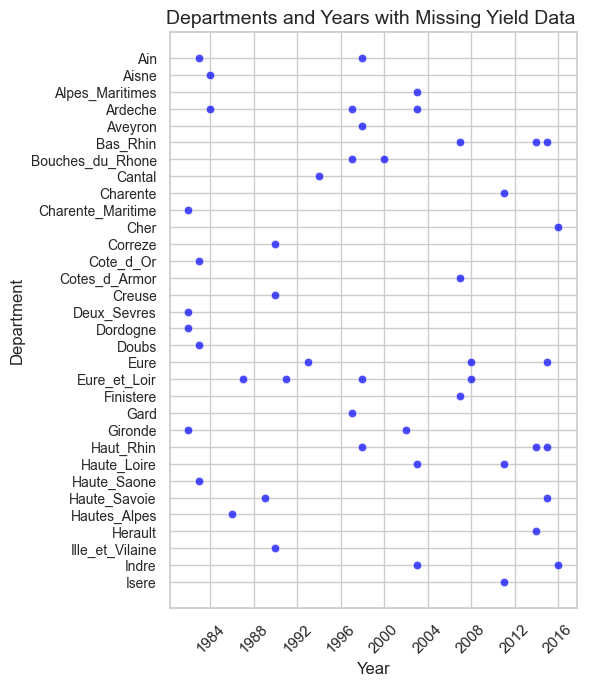

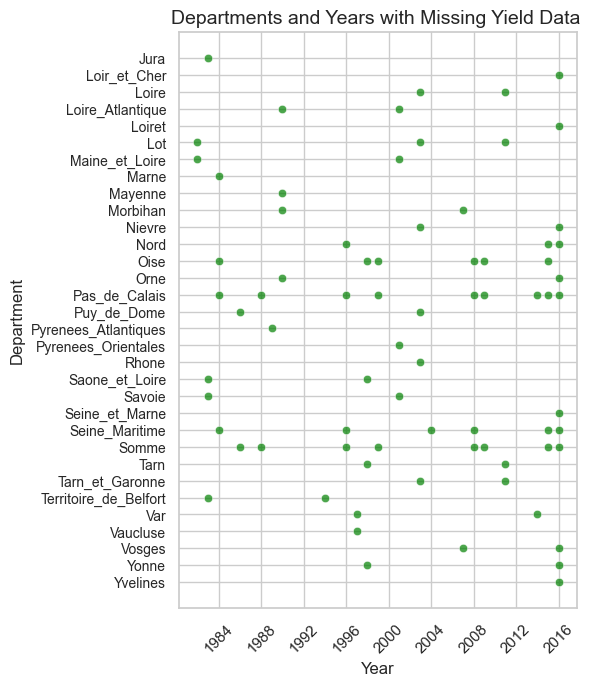

In [13]:
plt.figure(figsize=(6, 7))
sns.scatterplot(data=missing_yield_first_half, x='datetime', y='department', color='blue', alpha=0.7)
plt.title('Departments and Years with Missing Yield Data ', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(fontsize=10)
plt.tight_layout(pad=1)
plt.savefig("graph/missing_yield_data_first_half.png", bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(6, 7))
sns.scatterplot(data=missing_yield_second_half, x='datetime', y='department', color='green', alpha=0.7)
plt.title('Departments and Years with Missing Yield Data ', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(fontsize=10)
plt.tight_layout(pad=1)
plt.savefig("graph/missing_yield_data_second_half.png", bbox_inches='tight', dpi=300)
plt.show()

##### Yield Stationnarity


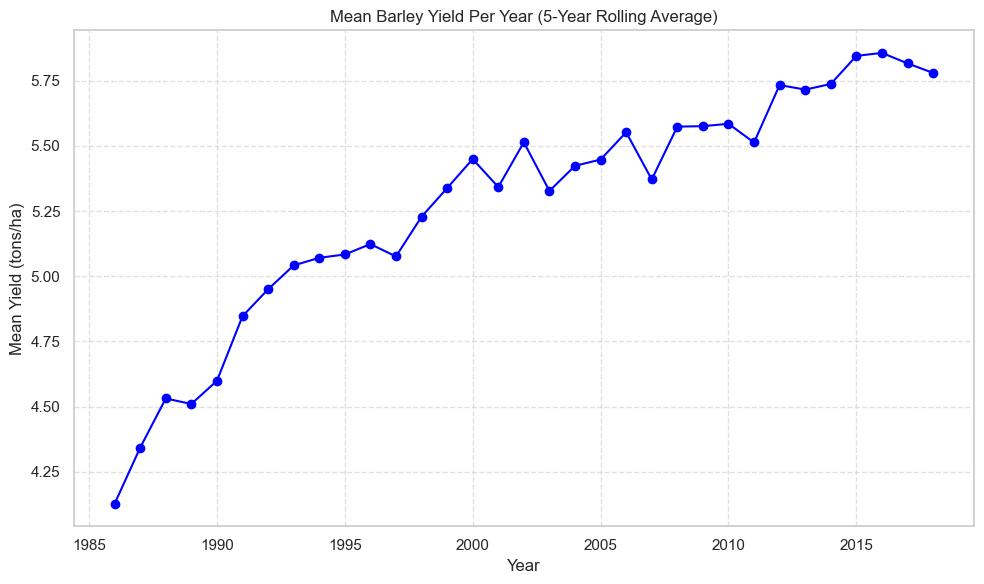

In [14]:
# Group by year and calculate the mean yield
mean_yield_per_year = df_yield.groupby(df_yield['datetime'].dt.year)['yield'].mean()
mean_yield_per_year = mean_yield_per_year.rolling(window=5).mean()

plt.figure(figsize=(10, 6))
mean_yield_per_year.plot(kind='line', marker='o', color='blue', title='Mean Barley Yield Per Year (5-Year Rolling Average)')
plt.xlabel('Year')
plt.ylabel('Mean Yield (tons/ha)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("graph/mean_yield_per_year.png", bbox_inches='tight', dpi=300)
plt.show()

##### Climate Shift
###### Climate Stripes" Heatmap (Year on X-axis, Month on Y-axis, Color = Temp Anomaly).

##### Climate Heat Stress Stripes


C:\Users\T\AppData\Local\Temp\ipykernel_8388\186678260.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_temp['year'] = filtered_temp['datetime'].dt.year
C:\Users\T\AppData\Local\Temp\ipykernel_8388\186678260.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_temp['month'] = filtered_temp['datetime'].dt.month
C:\Users\T\AppData\Local\Temp\ipykernel_8388\186678260.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

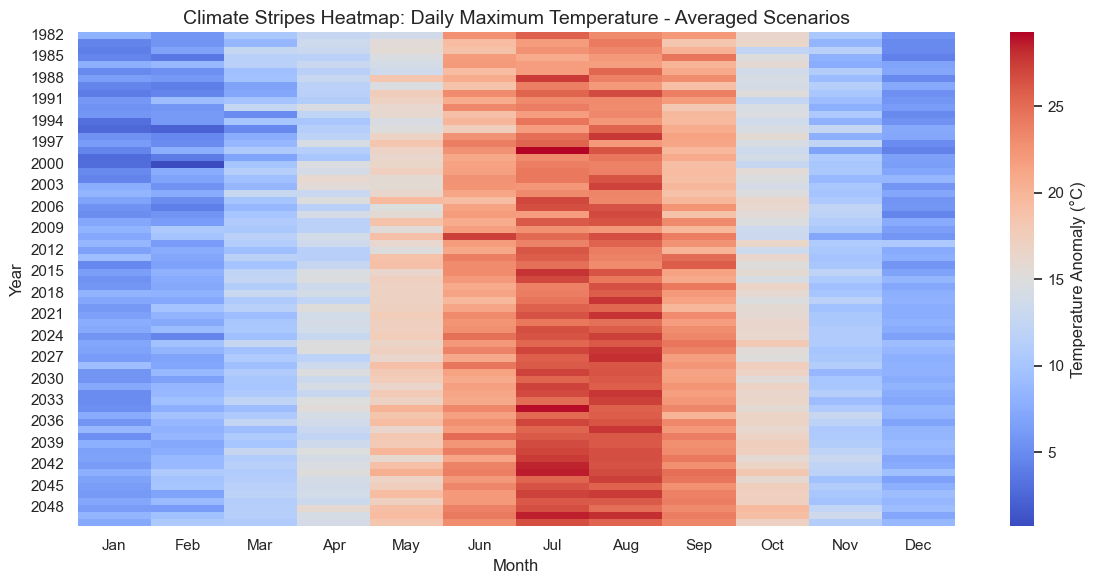

In [15]:
# Filter data for daily_maximum_near_surface_air_temperature
filtered_temp = df_climate[df_climate['metric'] == 'daily_maximum_near_surface_air_temperature']

# Extract year and month for grouping
filtered_temp['year'] = filtered_temp['datetime'].dt.year
filtered_temp['month'] = filtered_temp['datetime'].dt.month
filtered_temp['month'] = filtered_temp['month'].apply(lambda x: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][x - 1])
filtered_temp['month'] = pd.Categorical(filtered_temp['month'], categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], ordered=True)

# Calculate the mean temperature anomaly for each year and month
temp_anomaly = filtered_temp.groupby(['year', 'month'])['value'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(temp_anomaly, cmap='coolwarm', cbar_kws={'label': 'Temperature Anomaly (°C)'})
plt.title('Climate Stripes Heatmap: Daily Maximum Temperature - Averaged Scenarios', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig("graph/climate_stripes_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()

##### Drought Stripes


C:\Users\T\AppData\Local\Temp\ipykernel_8388\691908571.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_precip['year'] = filtered_precip['datetime'].dt.year
C:\Users\T\AppData\Local\Temp\ipykernel_8388\691908571.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_precip['month'] = filtered_precip['datetime'].dt.month
C:\Users\T\AppData\Local\Temp\ipykernel_8388\691908571.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

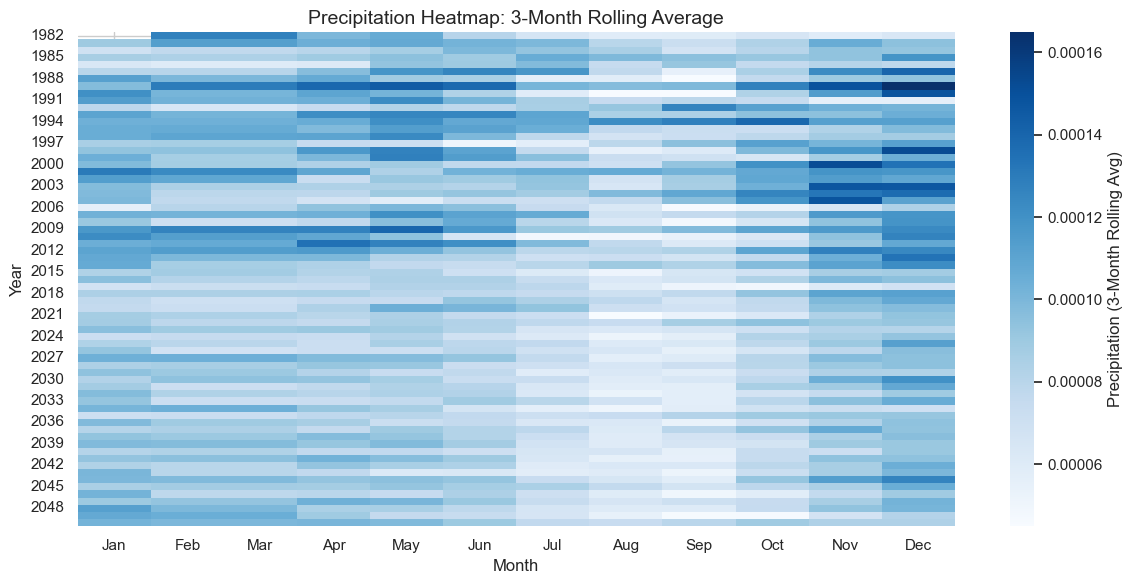

In [16]:
# Filter data for precipitation
filtered_precip = df_climate[df_climate['metric'] == 'precipitation']

# Extract year and month for grouping
filtered_precip['year'] = filtered_precip['datetime'].dt.year
filtered_precip['month'] = filtered_precip['datetime'].dt.month
filtered_precip['month'] = filtered_precip['month'].apply(lambda x: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][x - 1])
filtered_precip['month'] = pd.Categorical(filtered_precip['month'], categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], ordered=True)

# Calculate the mean precipitation for each year and month
precip_data = filtered_precip.groupby(['year', 'month'])['value'].mean().unstack()

# Apply a rolling average over 3 months
# Fill January with the rolling average including December of the previous year
precip_rolling_avg = precip_data.rolling(window=3, axis=1, min_periods=1).mean()
precip_rolling_avg['Jan'] = (precip_data['Dec'].shift(1) + precip_data['Jan'] + precip_data['Feb']) / 3
precip_rolling_avg['Feb'] = (precip_data['Jan'] + precip_data['Feb'] + precip_data['Mar']) / 3

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(precip_rolling_avg, cmap='Blues', cbar_kws={'label': 'Precipitation (3-Month Rolling Avg)'})
plt.title('Precipitation Heatmap: 3-Month Rolling Average', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.savefig("graph/precipitation_rolling_avg_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()

#### Feature Engineering

##### Climate-based features on a year basis


In [17]:
T_heat_stress = 25
T_extreme_shock = 30
T_frost = 0
P_DRY_DAY = 0.001    # 1mm
P_HEAVY_RAIN = 0.020  # 20mm

# Agronomic feature engineering

def engineer_features(df, scenario):
    features_list = []
    for (year, dept), group in df[(df['scenario'] == scenario)].groupby(['year', 'department']):
            
            ## WINTER PHASE (Jan-Feb)
            # Vernalization: Needs cold (0-10°C) to trigger flowering
            winter_mask = growing_season = group[group['datetime'].dt.month.isin([1, 2])]
            vernalization_days = winter_mask[(winter_mask['metric'] == 'near_surface_air_temperature') & (winter_mask['value'] > 0) & (winter_mask['value'] < 10)].shape[0]
            
            ## VEGETATIVE PHASE (Biomass Construction, Mar-Jun)
            growing_season = group[group['datetime'].dt.month.isin([3, 4, 5, 6])]
            # Variable: GDD (Growing Degree Days) -> Sum of (T_mean - Base)
            gdd = np.maximum(0, growing_season[growing_season['metric'] == 'daily_maximum_near_surface_air_temperature']['value']).sum()
            # Variable: Spring Rain (Hydric Potential)
            spring_rain = growing_season[growing_season['metric'] == 'precipitation']['value'].sum()
            # Variable : Aridity Index : Precip / (Temp + 10)
            t_avg_veget = growing_season[growing_season['metric'] == 'near_surface_air_temperature']['value'].mean()
            aridity_index = spring_rain / (t_avg_veget + 10) if (t_avg_veget + 10) > 0 else 0
            
            ## Summer FILLING PHASE (Yield Definition, May-June)
            filling_phase = group[group['datetime'].dt.month.isin([5, 6])]
            # Variable: Heat Stress (Scalding)
            heat_stress_days = (filling_phase[filling_phase['metric'] =='daily_maximum_near_surface_air_temperature']['value'] > T_heat_stress).sum()
            # Variable: Extreme Shock
            extreme_shock_days = (filling_phase[filling_phase['metric'] =='daily_maximum_near_surface_air_temperature']['value'] > T_extreme_shock).sum()
            # Variable: Compound Stress (Hot & Dry)
            compound_stress = ((filling_phase[filling_phase['metric'] =='daily_maximum_near_surface_air_temperature']['value'] > T_heat_stress) & (filling_phase[filling_phase['metric'] =='precipitation']['value'] < P_DRY_DAY)).sum()
            
            # C. RISK EVENTS
            # Variable: Late Frost (April)
            april_data = group[group['datetime'].dt.month == 4]
            late_frost_days = (2*april_data[april_data['metric'] == 'near_surface_air_temperature']['value'] - april_data[april_data['metric'] == 'daily_maximum_near_surface_air_temperature']['value'] < T_frost).sum() # calculus of minimum temperature
            # Variable: Wet Harvest (July)
            july_data = group[group['datetime'].dt.month == 7]
            wet_harvest_mm = july_data[july_data['metric'] == 'precipitation']['value'].sum()
            # Variable Heavy Rain Shock (July)
            heavy_rain_shock_days = (july_data[july_data['metric'] == 'precipitation']['value'] > P_HEAVY_RAIN).sum()

            features_list.append({
                'year': year,
                'department': dept,
                'bio_gdd_spring': gdd,
                'hydric_precip_spring': spring_rain,
                'stress_heat_days': heat_stress_days,
                'stress_shock_days': extreme_shock_days,
                'risk_frost_april': late_frost_days,
                'risk_wet_harvest': wet_harvest_mm,
                'risk_heavy_rain_july': heavy_rain_shock_days,
                'bio_vernalization_days': vernalization_days,
                'bio_aridity_index': aridity_index,
                'bio_compound_stress_days': compound_stress
            })

    df = pd.DataFrame(features_list)
    df['datetime']= pd.to_datetime(df['year'], format='%Y')
    df = df.drop(columns=['year'])
    
    return df

df_climate['year'] = df_climate['datetime'].dt.year

df_feat_yearly_historical = engineer_features(df_climate, 'historical')
df_feat_yearly_ssp585 = engineer_features(df_climate, 'ssp5_8_5')
df_feat_yearly_ssp126 = engineer_features(df_climate, 'ssp1_2_6')
df_feat_yearly_ssp245 = engineer_features(df_climate, 'ssp2_4_5')


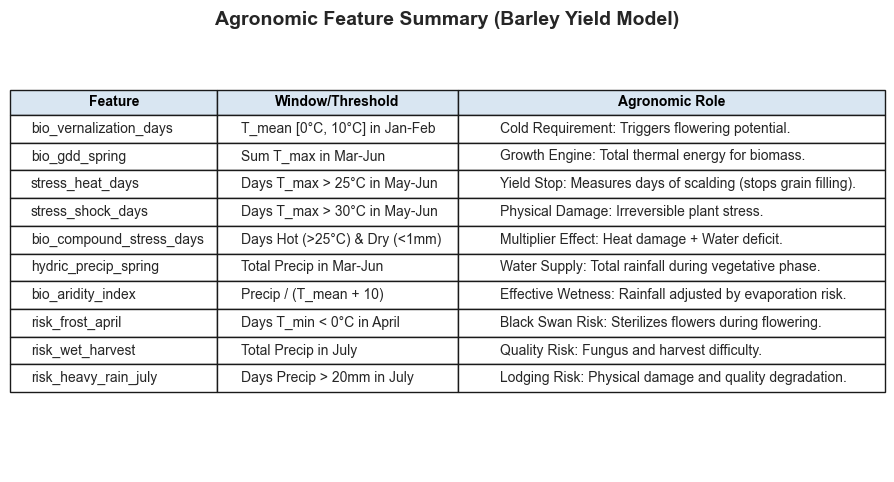

In [18]:
summary_data = [
    ["Feature", "Metric/Window", "Agronomic Role"],
    ["", "", ""], # Separator line
    
    ["bio_vernalization_days", "T_mean [0°C, 10°C] in Jan-Feb", "Cold Requirement: Triggers flowering potential."],
    ["bio_gdd_spring", "Sum T_max in Mar-Jun", "Growth Engine: Total thermal energy for biomass."],
    ["stress_heat_days", "Days T_max > 25°C in May-Jun", "Yield Stop: Measures days of scalding (stops grain filling)."],
    ["stress_shock_days", "Days T_max > 30°C in May-Jun", "Physical Damage: Irreversible plant stress."],
    ["bio_compound_stress_days", "Days Hot (>25°C) & Dry (<1mm)", "Multiplier Effect: Heat damage + Water deficit."],
    ["hydric_precip_spring", "Total Precip in Mar-Jun", "Water Supply: Total rainfall during vegetative phase."],
    ["bio_aridity_index", "Precip / (T_mean + 10)", "Effective Wetness: Rainfall adjusted by evaporation risk."],
    ["risk_frost_april", "Days T_min < 0°C in April", "Black Swan Risk: Sterilizes flowers during flowering."],
    ["risk_wet_harvest", "Total Precip in July", "Quality Risk: Fungus and harvest difficulty."],
    ["risk_heavy_rain_july", "Days Precip > 20mm in July", "Lodging Risk: Physical damage and quality degradation."],
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Convert data types for table creation
df_summary = pd.DataFrame(summary_data[2:], columns=summary_data[0])

table = ax.table(
    cellText=df_summary.values,
    colLabels=["Feature", "Window/Threshold", "Agronomic Role"],
    loc='center',
    cellLoc='left',
    colColours=['#f3f3f3', '#f3f3f3', '#f3f3f3']
)

# Styling for better readability
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df_summary.columns))))
table.scale(1.2, 1.5)

# Style the header row
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#d9e6f2')
    else:
        cell.set_height(0.06)

plt.title("Agronomic Feature Summary (Barley Yield Model)", y=0.95, fontsize=14, fontweight='bold')
plt.savefig("model_results/linear_agro_feature_summary.png", bbox_inches='tight', dpi=300)
plt.show()

##### Dataframes formatting for Train and Test

In [19]:
# Merge training (df_feat_yearly_historical + df_yield)
df_historical = df_yield.merge(df_feat_yearly_historical, on=['datetime', 'department'], how='inner')
print(tabulate(df_historical.head(), headers='keys', tablefmt='pretty', showindex=False))

+------------+--------------------+---------+------------+---------------------+--------------------+----------------------+------------------+-------------------+------------------+-----------------------+----------------------+------------------------+------------------------+--------------------------+
| department |       yield        |  area   | production |      datetime       |   bio_gdd_spring   | hydric_precip_spring | stress_heat_days | stress_shock_days | risk_frost_april |   risk_wet_harvest    | risk_heavy_rain_july | bio_vernalization_days |   bio_aridity_index    | bio_compound_stress_days |
+------------+--------------------+---------+------------+---------------------+--------------------+----------------------+------------------+-------------------+------------------+-----------------------+----------------------+------------------------+------------------------+--------------------------+
|    Ain     |      3.95008       | 16065.0 |  63458.0   | 1982-01-01 00:00:00 

###### Sanity NaN check

In [20]:
# Check for NaN values in df_historical
nan_summary = df_historical.isnull().sum()
print("\nSummary of NaN values in df_historical:")
print(tabulate(nan_summary[nan_summary > 0].reset_index(), headers=['Column', 'NaN Count'], tablefmt='pretty', showindex=False))

# Isolate rows with NaN values
nan_rows = df_historical[df_historical.isnull().any(axis=1)]
print("\nRows with NaN values in df_historical:")
print(tabulate(nan_rows, headers='keys', tablefmt='pretty', showindex=False))

# Interpolate missing values for 'production' and 'area' columns
df_historical['production'] = df_historical['production'].interpolate(method='linear', limit_direction='both')
df_historical['area'] = df_historical['area'].interpolate(method='linear', limit_direction='both')

# Verify interpolation
nan_summary_after = df_historical.isnull().sum()
print("\nSummary of NaN values in df_historical after interpolation:")
print(tabulate(nan_summary_after[nan_summary_after > 0].reset_index(), headers=['Column', 'NaN Count'], tablefmt='pretty', showindex=False))


Summary of NaN values in df_historical:
+------------+-----------+
|   Column   | NaN Count |
+------------+-----------+
|    area    |     2     |
| production |     5     |
+------------+-----------+

Rows with NaN values in df_historical:
+------------+-------------------+--------+------------+---------------------+--------------------+----------------------+------------------+-------------------+------------------+-----------------------+----------------------+------------------------+------------------------+--------------------------+
| department |       yield       |  area  | production |      datetime       |   bio_gdd_spring   | hydric_precip_spring | stress_heat_days | stress_shock_days | risk_frost_april |   risk_wet_harvest    | risk_heavy_rain_july | bio_vernalization_days |   bio_aridity_index    | bio_compound_stress_days |
+------------+-------------------+--------+------------+---------------------+--------------------+----------------------+------------------+------

#### Prédiction

##### Lin. trend + RF (Time Blind, Pure Climate) : Train

C:\Users\T\AppData\Local\Temp\ipykernel_8388\3953256995.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rf['dept_baseline'] = df_rf.groupby('department', group_keys=False).apply(calculate_trend_ridge)


   📂 Fold 1: MSE = 0.25 | RMSE = 0.02 | R2 = 0.83
   📂 Fold 2: MSE = 0.28 | RMSE = 0.02 | R2 = 0.82
   📂 Fold 3: MSE = 0.29 | RMSE = 0.02 | R2 = 0.83


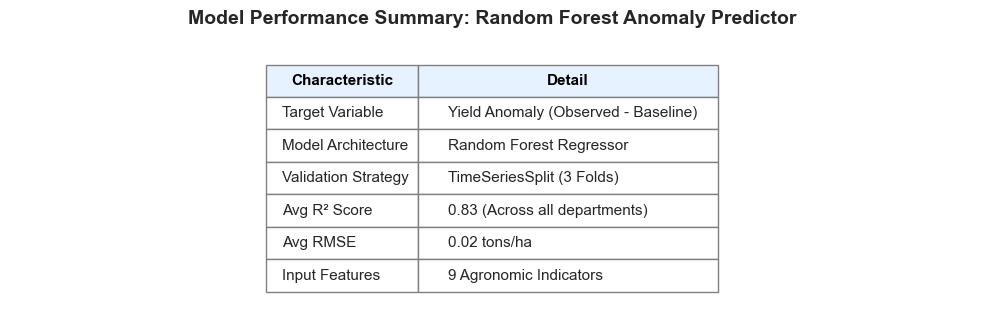

C:\Users\T\AppData\Local\Temp\ipykernel_8388\3953256995.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


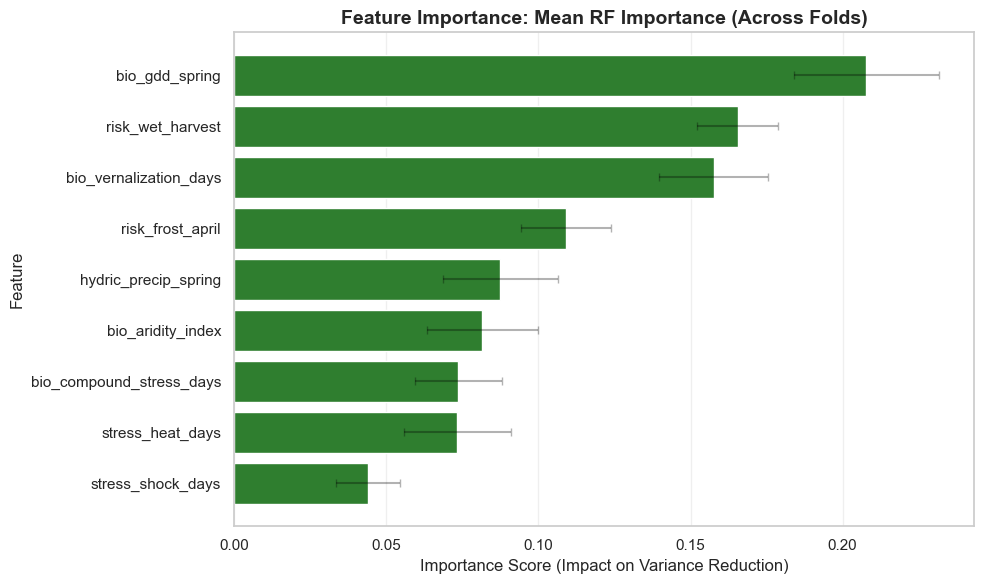

In [21]:
df_rf = df_historical.copy()
df_rf = df_rf.sort_values(['datetime', 'department'])
df_rf['year'] = df_rf['datetime'].dt.year

# --- Detrending baseline calculation ---
START_YEAR = df_rf['year'].min()
df_rf['log_time'] = np.log(df_rf['year'] - START_YEAR + 1)

# Features for the Linear Trend Model
trend_features = [
    'log_time', 
    'bio_gdd_spring', 'hydric_precip_spring', 'stress_heat_days', 
    'bio_vernalization_days', 'risk_wet_harvest', 'risk_frost_april', 
    'bio_aridity_index', 'bio_compound_stress_days'
]
# Ensure features exist
trend_features = [f for f in trend_features if f in df_rf.columns]

trend_models = {}
def calculate_trend_ridge(g):
    if len(g) < 10: return pd.Series(np.nan, index=g.index)
    # Pipeline: Scale -> Ridge (Alpha=0.1)
    m = make_pipeline(StandardScaler(), Ridge(alpha=0.1))
    m.fit(g[trend_features], g['yield'])
    trend_models[g.name] = m
    return pd.Series(m.predict(g[trend_features]), index=g.index)

# Apply detrending per department
df_rf['dept_baseline'] = df_rf.groupby('department', group_keys=False).apply(calculate_trend_ridge)
# Anomaly Calculation
df_rf['yield_anomaly'] = df_rf['yield'] - df_rf['dept_baseline']


# --- RANDOM FOREST REGRESSION ON ANOMALY ---
climate_features = [
    # 'year', 
    'bio_gdd_spring', 'hydric_precip_spring', 'stress_heat_days', 
    'stress_shock_days', 'risk_frost_april', 'risk_wet_harvest', 
    'bio_compound_stress_days', 'bio_aridity_index', 'bio_vernalization_days'
]
X = df_rf[[c for c in climate_features if c in df_rf.columns]]
y = df_rf['yield_anomaly'] # predicting the deviation

tscv = TimeSeriesSplit(n_splits=3)
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,         # Constrained depth
    min_samples_leaf=8,
    min_samples_split=10,  # Smoothing
    max_features=None, # Force feature diversity
    random_state=42,
    bootstrap=True,  
    n_jobs=-1
)
metrics = []
fold_importances = []
fold = 1

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model.fit(X_train, y_train)
    fold_importances.append(model.feature_importances_)
    # Predict Anomaly
    pred_anomaly = model.predict(X_test)
    # Final Prediction = Department Baseline + Predicted Climate Anomaly
    baseline_test = df_rf.iloc[test_idx]['dept_baseline']
    y_pred_final = baseline_test + pred_anomaly
    y_true_final = df_rf.iloc[test_idx]['yield']
    # Evaluate on REAL Yield
    mse = mean_squared_error(y_true_final, y_pred_final)
    rmse = np.sqrt(mse/len(y_true_final))
    r2 = r2_score(y_true_final, y_pred_final)
    
    print(f"   📂 Fold {fold}: MSE = {mse:.2f} | RMSE = {rmse:.2f} | R2 = {r2:.2f}")
    metrics.append({'Fold': fold, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    fold += 1

importance_matrix = np.array(fold_importances)
mean_importance = np.mean(importance_matrix, axis=0)
std_importance = np.std(importance_matrix, axis=0)
importance_summary = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Importance': mean_importance,
    'Std_Dev': std_importance
}).set_index('Feature').sort_values('Mean_Importance', ascending=False)

# --- VISUALIZATION---
metrics_df = pd.DataFrame(metrics)
avg_r2 = metrics_df['R2'].mean()
avg_rmse = metrics_df['RMSE'].mean()
# Model Summary Table
summary_model_data = [
    ["Target Variable", "Yield Anomaly (Observed - Baseline)"],
    ["Model Architecture", "Random Forest Regressor"],
    ["Validation Strategy", "TimeSeriesSplit (3 Folds)"],
    ["Avg R² Score", f"{avg_r2:.2f} (Across all departments)"],
    ["Avg RMSE", f"{avg_rmse:.2f} tons/ha"],
    ["Input Features", f"{len(X.columns)} Agronomic Indicators"]
]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')
table = ax.table(
    cellText=summary_model_data, 
    colLabels=["Characteristic", "Detail"], 
    loc='center',
    cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(summary_model_data[0]))))
table.scale(1.2, 1.8)
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#e6f2ff')
    cell.set_edgecolor('gray')
plt.title("Model Performance Summary: Random Forest Anomaly Predictor", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model_results/rf_model_summary.png", bbox_inches='tight', dpi=300)
plt.show()

# Feature Importance Plot
plt.figure(figsize=(10, 6))
# RF Importances are always positive, so we use a single color (Green for 'Driver')
colors = ['forestgreen' for _ in importance_summary['Mean_Importance']]
sns.barplot(
    x=importance_summary['Mean_Importance'],
    y=importance_summary.index,
    palette=colors
)
plt.errorbar(
    x=importance_summary['Mean_Importance'], 
    y=range(len(importance_summary)), 
    xerr=importance_summary['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3, 
    alpha=0.3
)
plt.title('Feature Importance: Mean RF Importance (Across Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Impact on Variance Reduction)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("model_results/rf_feature_importance_plot.png", dpi=300)
plt.show()

##### Lin. trend + RF (Time Blind, Pure Climate) : Application to Scenarios

In [ ]:
scenarios = {
    "SSP5-8.5": df_feat_yearly_ssp585,
    "SSP1-2.6": df_feat_yearly_ssp126, 
    "SSP2-4.5": df_feat_yearly_ssp245
}

for scenario_name, df_source in scenarios.items():
    print(f"   Processing {scenario_name}...")
    df_future = df_source.copy()

    # 1. Feature Engineering
    if 'year' not in df_future.columns:
        df_future['year'] = df_future['datetime'].dt.year
        
    df_future['log_time'] = np.log(df_future['year'] - START_YEAR + 1)

    # 2. Predict Baseline (Using PRE-TRAINED Trend Models)
    def predict_baseline(g):
        dept = g.name
        if dept in trend_models:
            return pd.Series(trend_models[dept].predict(g[trend_features]), index=g.index)
        return pd.Series(np.nan, index=g.index)

    df_future['pred_baseline'] = df_future.groupby('department', group_keys=False).apply(predict_baseline)

    # 3. Predict Anomaly (Using PRE-TRAINED RF Model)
    rf_model = model  # The trained Random Forest model from above
    rf_features = climate_features
    X_future = df_future[rf_features].fillna(0)
    df_future['pred_anomaly'] = rf_model.predict(X_future)

    # 4. Final Yield & Export
    df_future['predicted_yield'] = df_future['pred_baseline'] + df_future['pred_anomaly']
    
    # Save
    filename = f"model_results/predicted_yield_{scenario_name}.csv"
    if os.path.exists(filename):
        os.remove(filename)
    df_future.to_csv(filename, index=False)

   Processing SSP5-8.5...


C:\Users\T\AppData\Local\Temp\ipykernel_8388\910374458.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_future['pred_baseline'] = df_future.groupby('department', group_keys=False).apply(predict_baseline)


   Processing SSP1-2.6...


C:\Users\T\AppData\Local\Temp\ipykernel_8388\910374458.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_future['pred_baseline'] = df_future.groupby('department', group_keys=False).apply(predict_baseline)


   Processing SSP2-4.5...


C:\Users\T\AppData\Local\Temp\ipykernel_8388\910374458.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_future['pred_baseline'] = df_future.groupby('department', group_keys=False).apply(predict_baseline)


##### Lin. trend

###### Model Summary Table

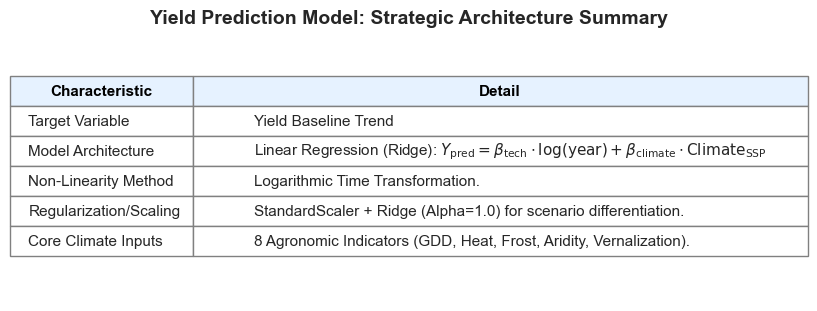

In [ ]:
summary_model_data = [
    ["Target Variable", "Yield Baseline Trend"],
    ["Model Architecture", r"Linear Regression (Ridge): $Y_{\text{pred}} = \beta_{\text{tech}} \cdot \log(\text{year}) + \beta_{\text{climate}} \cdot \text{Climate}_{\text{SSP}}$"],
    ["Non-Linearity Method", "Logarithmic Time Transformation."],
    ["Regularization/Scaling", "StandardScaler + Ridge (Alpha=1.0) for scenario differentiation."],
    ["Core Climate Inputs", "8 Agronomic Indicators (GDD, Heat, Frost, Aridity, Vernalization)."],
]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

table = ax.table(
    cellText=summary_model_data, 
    colLabels=["Characteristic", "Detail"], 
    loc='center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(summary_model_data[0]))))
table.scale(1.2, 1.8)

# Header styling
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#e6f2ff')
    cell.set_edgecolor('gray')

plt.title("Yield Prediction Model: Strategic Architecture Summary", fontsize=14, fontweight='bold')
plt.savefig("model_results/linear_model_summary.png", bbox_inches='tight', dpi=300)
plt.show()

###### Visualization

In [94]:
# 1. LOAD & PREPARE HISTORICAL DATA (The Bridge)
# ==============================================================================
if 'df_historical' in locals() and not df_historical.empty:
    df_hist_proc = df_historical.copy()
    if 'datetime' in df_hist_proc.columns:
        df_hist_proc['datetime'] = pd.to_datetime(df_hist_proc['datetime'])
    
    # Calculate National Observed Yield
    df_national_hist = df_hist_proc.groupby('datetime', as_index=False)['yield'].mean()
    
    # Smooth History
    df_national_hist['pred_baseline'] = df_national_hist['yield'].rolling(window=5, min_periods=1).mean()
    df_national_hist['Scenario'] = 'Historical Observed'
else:
    print("⚠️ df_historical not found. Using mock historical data.")
    dates = pd.date_range('2000-01-01', '2024-01-01', freq='Y')
    df_national_hist = pd.DataFrame({
        'datetime': dates,
        'pred_baseline': np.linspace(60, 75, len(dates)) + np.random.normal(0, 2, len(dates)),
        'Scenario': 'Historical Observed'
    })
    df_national_hist['pred_baseline'] = df_national_hist['pred_baseline'].rolling(window=5, min_periods=1).mean()

# 2. LOAD SCENARIO DATA
# ==============================================================================
scenarios = ["SSP1-2.6", "SSP2-4.5", "SSP5-8.5"]
data_frames = []

for sc in scenarios:
    fname = f"model_results/predicted_yield_{sc}.csv"
    if not os.path.exists(fname):
        if "SSP1" in sc: fname = "model_results/predicted_yield_SSP1-2.6 (Optimistic).csv"
        elif "SSP2" in sc: fname = "model_results/predicted_yield_SSP2-4.5 (Middle).csv"
        elif "SSP5" in sc: fname = "model_results/predicted_yield_SSP5-8.5 (Pessimistic).csv"
    
    try:
        df = pd.read_csv(fname).assign(Scenario=sc)
        data_frames.append(df)
    except FileNotFoundError:
        print(f"⚠️ Missing: {fname}")

if data_frames:
    df_combined = pd.concat(data_frames)
    if 'datetime' in df_combined.columns:
        df_combined['datetime'] = pd.to_datetime(df_combined['datetime'])

    # Aggregate to National Level
    df_national_raw = df_combined.groupby(['datetime', 'Scenario'], as_index=False)['pred_baseline'].mean()

    # 3. APPLY BRIDGE SMOOTHING (The Fix)
    # ==============================================================================
    smoothed_frames = []
    
    for sc in scenarios:
        # Get just this scenario's future data
        sc_future = df_national_raw[df_national_raw['Scenario'] == sc].sort_values('datetime')
        
        if sc_future.empty: continue

        # BRIDGE: Concat History + Future
        hist_bridge = df_national_hist[['datetime', 'pred_baseline']].copy()
        
        # Combine
        combined_series = pd.concat([hist_bridge, sc_future[['datetime', 'pred_baseline']]])
        combined_series = combined_series.sort_values('datetime').drop_duplicates('datetime')
        
        # Apply Rolling Average on the CONTINUOUS series
        combined_series['pred_baseline'] = combined_series['pred_baseline'].rolling(window=5, min_periods=1).mean()
        
        # Slice back: Keep only the dates that belong to the future scenario
        future_smoothed = combined_series[combined_series['datetime'].isin(sc_future['datetime'])].copy()
        future_smoothed['Scenario'] = sc
        
        smoothed_frames.append(future_smoothed)

    df_national = pd.concat(smoothed_frames)
else:
    df_national = pd.DataFrame()

# 4. PLOT
# ==============================================================================
# Combine History and Smoothed Futures for plotting
plot_df = pd.concat([df_national, df_national_hist])

fig = px.line(
    plot_df,
    x='datetime',
    y='pred_baseline',
    color='Scenario',
    title='Average Yield Trend',
    labels={'datetime': 'Year', 'pred_baseline': 'Average Yield (tons/ha)', 'Scenario': 'Scenario'},
    color_discrete_map={
        'SSP1-2.6': '#2ca02c', # Green
        'SSP2-4.5': '#ff7f0e', # Orange
        'SSP5-8.5': '#d62728', # Red
        'Historical Observed': 'gray'
    }
)
fig.for_each_trace(lambda t: t.update(line_dash='dash') if t.name in scenarios else t.update(line_dash='solid', line_width=3))

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Yield (tons/ha)",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.3, xanchor="center", x=0.5)
)
fig.write_image("model_results/yield_trend_evolution.png")
fig.show()

##### Visualization 5 departments

In [23]:
scenarios = [
    "SSP1-2.6", 
    "SSP2-4.5", 
    "SSP5-8.5"
]
df_combined = pd.concat([
    pd.read_csv(f"model_results/predicted_yield_{sc}.csv").assign(Scenario=sc) for sc in scenarios
])
df_combined['datetime'] = pd.to_datetime(df_combined['datetime'])
df_combined['year'] = df_combined['datetime'].dt.year

TARGET_DEPARTMENTS = ['Isere', 'Cher', 'Somme', 'Haute_Garonne', 'Essonne']
df_combined = df_combined[df_combined['department'].isin(TARGET_DEPARTMENTS)]

In [ ]:
# Calculate the mean, maximum, and minimum predicted yield for each year across scenarios
df_mean_max_min = df_combined.groupby(['year', 'department']).agg(
    mean_predicted_yield=('predicted_yield', 'mean'),
    max_predicted_yield=('predicted_yield', 'max'),
    min_predicted_yield=('predicted_yield', 'min')
).reset_index()

# Define a color palette for departments
department_colors = {dept: color for dept, color in zip(df_mean_max_min['department'].unique(), qualitative.Set1)}

# Plot the mean curve with a shaded area for the maxima and minima
fig = go.Figure()

# Add the mean predicted yield curve
for department in df_mean_max_min['department'].unique():
    dept_data = df_mean_max_min[df_mean_max_min['department'] == department]
    fig.add_trace(go.Scatter(
        x=dept_data['year'],
        y=dept_data['mean_predicted_yield'],
        mode='lines',
        name=f"{department}",
        line=dict(color=department_colors[department])
    ))

    # Add the shaded area for the maxima and minima
    fig.add_trace(go.Scatter(
        x=pd.concat([dept_data['year'], dept_data['year'][::-1]]),
        y=pd.concat([dept_data['max_predicted_yield'], dept_data['min_predicted_yield'][::-1]]),
        fill='toself',
        fillcolor=department_colors[department].replace('rgb', 'rgba').replace(')', ', 0.2)'),  # Add transparency
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=False
    ))

# Update layout
fig.update_layout(
    title="Average Predicted Yield with Uncertainty Range",
    xaxis_title="Year",
    yaxis_title="Predicted Yield (tons/ha)",
    template="plotly_white",
    legend=dict(
        orientation="h",  # Horizontal legend
        yanchor="bottom",
        y=-0.3,  # Move legend below the plot
        xanchor="center",
        x=0.5
    )
)

# Increase the figure size to reduce compression
fig.update_layout(width=1000, height=600)

fig.write_image("predicted_yield_mean_uncertainty.png")
fig.show()

##### Risk and Volatility Measure

###### Proba of Failure

C:\Users\T\AppData\Local\Temp\ipykernel_8388\3297473975.py:21: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\T\AppData\Local\Temp\ipykernel_8388\3297473975.py:21: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\T\AppData\Local\Temp\ipykernel_8388\3297473975.py:21: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the

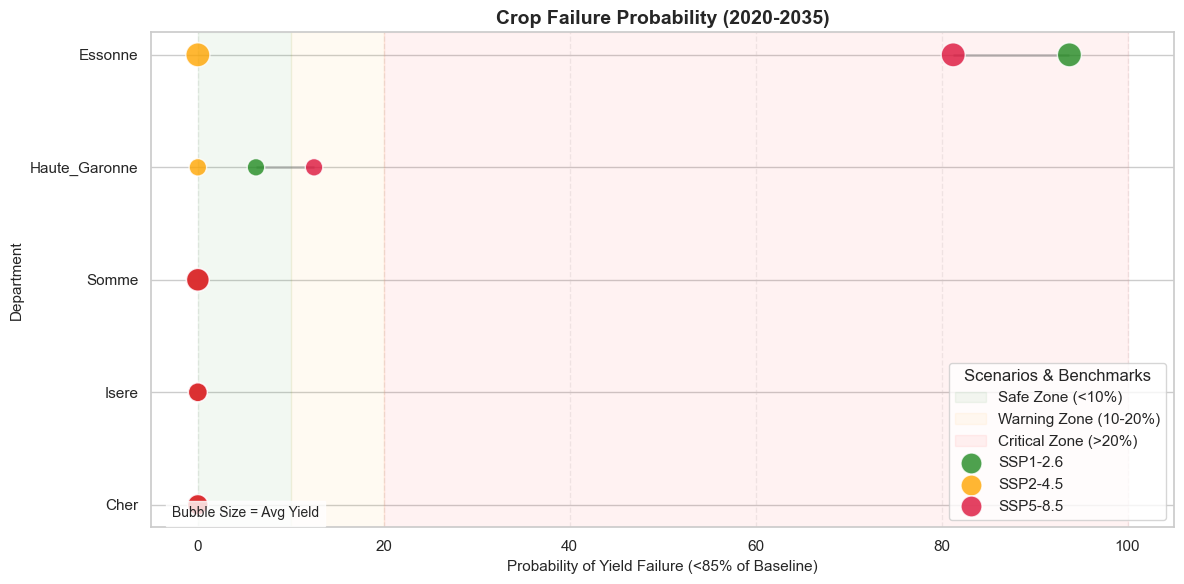

In [35]:
period_ST = df_combined[(df_combined['year'] >= 2020) & (df_combined['year'] <= 2035)]

# Define Failure Threshold (10th percentile of 2025 baseline)
failure_thresh_coeff=0.85
thresholds = df_combined[df_combined['year'] == 2025].groupby('department')['pred_baseline'].mean() * failure_thresh_coeff
def calc_pof(g):
    dept = g.name
    thresh = thresholds.get(dept, 60)
    failures = (g['predicted_yield'] < thresh).sum()
    return (failures / len(g)) * 100
# Calculate PoF for Future Scenarios
scenarios = ["SSP1-2.6", "SSP2-4.5", "SSP5-8.5"]
available_scenarios = df_combined['Scenario'].unique()
target_scenarios = []
for s in scenarios:
    match = [x for x in available_scenarios if s in x]
    if match: target_scenarios.append(match[0])
pof_data = {}
for sc in target_scenarios:
    scenario_data = period_ST[period_ST['Scenario'] == sc]
    pof_data[sc] = scenario_data.groupby('department').apply(calc_pof)
# Calculate Historical PoF (The Benchmark)
hist_data = df_combined[df_combined['Scenario'] == 'Historical']
if not hist_data.empty:
    # We use the last 15 years of history for a fair comparison
    hist_recent = hist_data[hist_data['year'] > hist_data['year'].max() - 15]
    pof_data['Historical'] = hist_recent.groupby('department').apply(calc_pof)

# Calculate Importance (Average Yield) for Bubble Size
dept_yields = period_ST.groupby('department')['predicted_yield'].mean()

# Combine into Master DataFrame
pof_df = pd.DataFrame(pof_data)
pof_df['Avg_Yield'] = dept_yields
pof_df = pof_df.sort_values(by=target_scenarios[-1], ascending=True) # Sort by worst case

# 2. PLOTTING
fig, ax = plt.subplots(figsize=(12, max(6, len(pof_df) * 0.4)))
# A. Risk Zones (Background Shading)
ax.axvspan(0, 10, color='green', alpha=0.05, label='Safe Zone (<10%)')
ax.axvspan(10, 20, color='orange', alpha=0.05, label='Warning Zone (10-20%)')
ax.axvspan(20, 100, color='red', alpha=0.05, label='Critical Zone (>20%)')

# B. The "Range" Lines (Grey bars)
# Connect Best Case (SSP1) to Worst Case (SSP5)
plt.hlines(y=pof_df.index, xmin=pof_df[target_scenarios[0]], xmax=pof_df[target_scenarios[-1]], 
           color='grey', alpha=0.4, linewidth=2, zorder=1)

# C. Plot Scenarios (Bubbles sized by Yield)
colors = {'Historical': 'black', target_scenarios[0]: 'forestgreen', target_scenarios[1]: 'orange', target_scenarios[2]: 'crimson'}
markers = {'Historical': '|'} # Use a tick for history

# Plot History (as a benchmark tick)
if 'Historical' in pof_df.columns:
    plt.scatter(pof_df['Historical'], pof_df.index, color='black', marker='|', s=150, 
                label='Historical Benchmark', zorder=4, linewidth=3)

# Plot Future Scenarios (as bubbles)
for sc in target_scenarios:
    # Scale size: Min 20, Max 300 based on yield
    sizes = (pof_df['Avg_Yield'] / pof_df['Avg_Yield'].max()) * 300
    plt.scatter(pof_df[sc], pof_df.index, s=sizes, color=colors.get(sc, 'blue'), 
                label=sc, alpha=0.8, edgecolors='white', zorder=3)

# D. Annotations
plt.title("Crop Failure Probability (2020-2035)", fontsize=14, fontweight='bold')
plt.xlabel(f"Probability of Yield Failure (<{int(failure_thresh_coeff * 100)}% of Baseline)", fontsize=11)
plt.ylabel("Department", fontsize=11)

# Legend (Fixing duplicates and sizing)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='lower right', title="Scenarios & Benchmarks")

# Add Size Legend explanation
plt.text(0.02, 0.02, "Bubble Size = Avg Yield", transform=ax.transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("agronomic_risk_pof.png", dpi=300)
plt.show()

###### Volatility Coefficient

📊 Computing Volatility (CV) for SSP1-2.6...
📊 Computing Volatility (CV) for SSP2-4.5...
📊 Computing Volatility (CV) for SSP5-8.5...


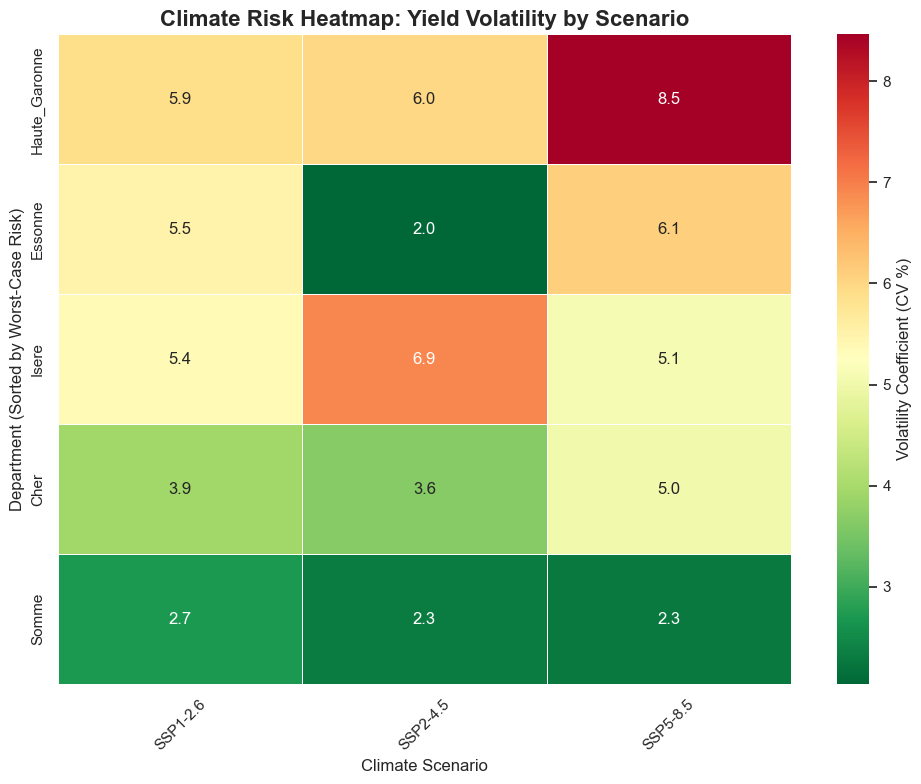


⚠️ CRITICAL WATCHLIST (Top 5 Highest Volatility in Worst Case):
department       SSP1-2.6    SSP2-4.5    SSP5-8.5
-------------  ----------  ----------  ----------
Haute_Garonne        5.89        5.98        8.46
Essonne              5.51        2.04        6.10
Isere                5.37        6.91        5.10
Cher                 3.93        3.65        5.01
Somme                2.70        2.31        2.27


In [ ]:
def compute_cv_metric(df_input, scenario_name):
    print(f"📊 Computing Volatility (CV) for {scenario_name}...")
    
    # Filter for specific scenario
    # Ensure we work on a copy to avoid SettingWithCopy warnings
    df_sc = df_input[df_input['Scenario'] == scenario_name].copy()
    
    # 1. Group by Department to analyze time-series stability
    stats = df_sc.groupby('department')['predicted_yield'].agg(['mean', 'std'])
    
    # 2. Calculate CV
    # Handle edge case where Mean is 0 to avoid DivisionByZero
    stats['Volatility_CV'] = stats.apply(
        lambda row: (row['std'] / row['mean'] * 100) if row['mean'] > 0 else 0.0, 
        axis=1
    )
    
    # 3. Formatting
    stats = stats.rename(columns={'mean': 'Avg_Yield', 'std': 'Std_Dev'})
    return stats.sort_values('Volatility_CV', ascending=True) # Stable to Volatile

# --- EXECUTION & VISUALIZATION ---

# 1. Load Data (Robust Load Logic)
try:
    # Check if df_combined exists in memory (from previous steps)
    if 'df_combined' not in locals():
        # Reconstruct if missing (Fallback to loading individual files)
        scenarios = ["SSP1-2.6", "SSP2-4.5", "SSP5-8.5"]
        # Use simple mapping if filenames are standard
        # Note: You might need to adjust filenames based on your exact saved outputs
        df_list = []
        for sc in scenarios:
            fname = f"model_results/predicted_yield_{sc}.csv"
            # Try to match the filename pattern used in previous scripts
            if "SSP1" in sc: fname = "model_results/predicted_yield_SSP1-2.6 (Optimistic).csv"
            elif "SSP2" in sc: fname = "model_results/predicted_yield_SSP2-4.5 (Middle).csv"
            elif "SSP5" in sc: fname = "model_results/predicted_yield_SSP5-8.5 (Pessimistic).csv"
            
            try:
                tmp = pd.read_csv(fname)
                tmp['Scenario'] = sc # Ensure scenario column exists
                df_list.append(tmp)
            except FileNotFoundError:
                print(f"⚠️ Warning: Could not load {fname}")
        
        if df_list:
            df_combined = pd.concat(df_list)
        else:
            raise FileNotFoundError("No scenario data found.")

    # 2. Calculate CV for ALL Scenarios
    scenarios = df_combined['Scenario'].unique()
    cv_results = []
    
    for sc in scenarios:
        res = compute_cv_metric(df_combined, sc)
        res['Scenario'] = sc
        cv_results.append(res)
    
    all_cv = pd.concat(cv_results).reset_index()

    # 3. PIVOT FOR HEATMAP (Dept x Scenario)
    # This creates a matrix where we can compare risk across futures
    heatmap_data = all_cv.pivot(index='department', columns='Scenario', values='Volatility_CV')
    
    # 4. SORTING STRATEGY (Business Logic)
    # Sort by the "Worst Case" scenario (SSP5-8.5) descending.
    # Top of the chart = Most Volatile under climate stress.
    sort_col = [c for c in heatmap_data.columns if 'SSP5' in c]
    if sort_col:
        heatmap_data = heatmap_data.sort_values(sort_col[0], ascending=False)
    else:
        heatmap_data = heatmap_data.sort_values(heatmap_data.columns[-1], ascending=False)

    # 5. PLOT HEATMAP
    # Dynamic height: 0.25 inches per department ensures readability
    plt.figure(figsize=(10, max(8, len(heatmap_data) * 0.25)))
    
    sns.heatmap(
        heatmap_data, 
        cmap='RdYlGn_r', # Red (High Risk) to Green (Low Risk)
        annot=True,      # Show the actual CV% numbers
        fmt=".1f",       # 1 decimal place
        linewidths=0.5,
        cbar_kws={'label': 'Volatility Coefficient (CV %)'}
    )
    
    plt.title("Climate Risk Heatmap: Yield Volatility by Scenario", fontsize=16, fontweight='bold')
    plt.xlabel("Climate Scenario", fontsize=12)
    plt.ylabel("Department (Sorted by Worst-Case Risk)", fontsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig("volatility_risk_heatmap.png", dpi=300)
    plt.show()

    # 6. REPORT TOP RISKS
    print("\n⚠️ CRITICAL WATCHLIST (Top 5 Highest Volatility in Worst Case):")
    print(tabulate(heatmap_data.head(5), headers='keys', tablefmt='simple', floatfmt=".2f"))

except Exception as e:
    print(f"Error in CV calculation/plotting: {e}")

###### Portfolio Sourcing Scenarios

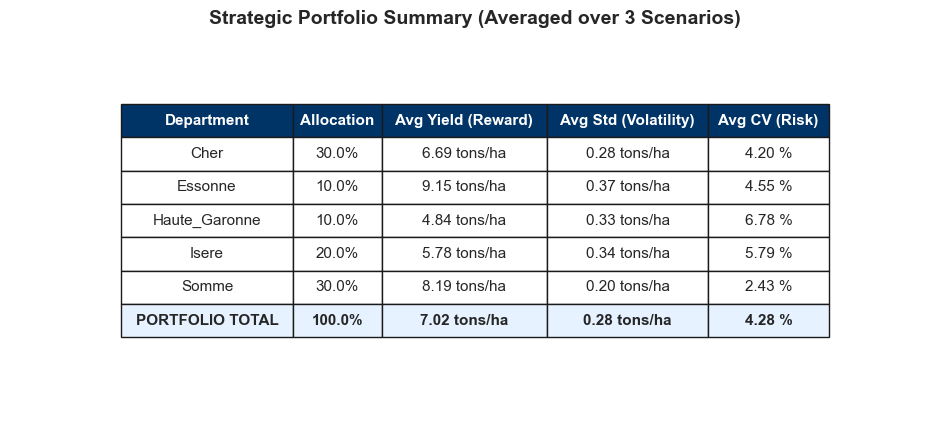

✅ Portfolio Table saved as 'portfolio_summary.png'


In [57]:
def evaluate_weighted_portfolio(df_all_scenarios, weights_dict):
    # 1. Filter Data
    df_port = df_all_scenarios[df_all_scenarios['department'].isin(weights_dict.keys())].copy()
    
    if df_port.empty:
        print("⚠️ No data found for the requested departments.")
        return

    # 2. Calculate Metrics per Scenario per Department
    scenarios = df_port['Scenario'].unique()
    scenario_stats = []
    
    for sc in scenarios:
        sub = df_port[df_port['Scenario'] == sc]
        stats = sub.groupby('department')['predicted_yield'].agg(['mean', 'std'])
        stats['CV'] = (stats['std'] / stats['mean']) * 100 if stats['mean'].mean() > 0 else 0
        scenario_stats.append(stats)
        
    all_stats = pd.concat(scenario_stats).reset_index()
    
    # 3. Average Metrics OVER Scenarios
    dept_avg = all_stats.groupby('department')[['mean', 'std', 'CV']].mean().reset_index()
    dept_avg.columns = ['Department', 'Avg_Yield', 'Avg_Std', 'Avg_CV']
    
    # 4. Apply Portfolio Weights
    dept_avg['Weight'] = dept_avg['Department'].map(weights_dict)
    
    total_weight = dept_avg['Weight'].sum()
    if not np.isclose(total_weight, 1.0):
        dept_avg['Weight'] = dept_avg['Weight'] / total_weight
        
    # 5. Weighted Portfolio Totals
    w_yield = (dept_avg['Avg_Yield'] * dept_avg['Weight']).sum()
    w_std = (dept_avg['Avg_Std'] * dept_avg['Weight']).sum()
    w_cv = (dept_avg['Avg_CV'] * dept_avg['Weight']).sum()
    
    # 6. Generate Visual Table
    # Prepare Data for Table
    plot_df = dept_avg[['Department', 'Weight', 'Avg_Yield', 'Avg_Std', 'Avg_CV']].copy()
    
    # Add Total Row
    total_row = pd.DataFrame({
        'Department': ['PORTFOLIO TOTAL'],
        'Weight': [1.0],
        'Avg_Yield': [w_yield],
        'Avg_Std': [w_std],
        'Avg_CV': [w_cv]
    })
    plot_df = pd.concat([plot_df, total_row], ignore_index=True)
    
    # Formatting for display
    cell_text = []
    for _, row in plot_df.iterrows():
        cell_text.append([
            row['Department'],
            f"{row['Weight']:.1%}",
            f"{row['Avg_Yield']:.2f} tons/ha",
            f"{row['Avg_Std']:.2f} tons/ha",
            f"{row['Avg_CV']:.2f} %"
        ])

    # Plot
    fig, ax = plt.subplots(figsize=(12, len(plot_df) * 0.6 + 1.5))
    ax.axis('off')
    
    table = ax.table(
        cellText=cell_text,
        colLabels=['Department', 'Allocation', 'Avg Yield (Reward)', 'Avg Std (Volatility)', 'Avg CV (Risk)'],
        loc='center',
        cellLoc='center'
    )
    
    # Styling
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.0)
    table.auto_set_column_width(col=list(range(5)))
    
    # Highlight Header and Total Row
    for (i, j), cell in table.get_celld().items():
        if i == 0: # Header
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#003366') # Dark Blue
        elif i == len(plot_df): # Total Row
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e6f2ff') # Light Blue
    
    plt.title(f"Strategic Portfolio Summary (Averaged over {len(scenarios)} Scenarios)", fontsize=14, fontweight='bold', y=0.98)
    plt.savefig("portfolio_summary.png", bbox_inches='tight', dpi=300)
    plt.show()
    print("✅ Portfolio Table saved as 'portfolio_summary.png'")

# --- EXECUTION ---

# Define Portfolio Weights
my_portfolio = {
    'Isere': 0.2,
    'Haute_Garonne': 0.1,
    'Cher': 0.3,
    'Somme': 0.3,
    'Essonne': 0.1
}

# Run Evaluator (Assumes df_combined exists)
if 'df_combined' in locals():
    evaluate_weighted_portfolio(df_combined, my_portfolio)
else:
    print("⚠️ df_combined not found in memory.")

##### Linear yield trend Baseline prediciton - Curve Plateau Regression

###### Model

In [ ]:
df_trend = df_historical.sort_values(['datetime', 'department']).copy()
df_trend['year'] = df_trend['datetime'].dt.year
START_YEAR = df_trend['year'].min()
df_trend['log_time'] = np.log(df_trend['year'] - START_YEAR + 1) 

features = [
    'log_time', 
    'bio_gdd_spring', 'hydric_precip_spring', 'stress_heat_days', 
    'bio_vernalization_days', 'risk_wet_harvest', 'risk_frost_april', 
    'bio_aridity_index', 'bio_compound_stress_days'
]
features = [f for f in features if f in df_trend.columns] 

models = {}
metrics = []

def train_and_evaluate(g):
    if len(g) < 10: 
        metrics.append({'department': g.name, 'R2': np.nan, 'RMSE': np.nan, 'T_Growth_Coeff': np.nan, 'T_Heat_Coeff': np.nan})
        return pd.Series(np.nan, index=g.index)
    m = make_pipeline(StandardScaler(), Ridge(alpha=0.1))
    m.fit(g[features], g['yield'])
    models[g.name] = m
    y_pred = m.predict(g[features])
    r2 = r2_score(g['yield'], y_pred)
    rmse = np.sqrt(mean_squared_error(g['yield'], y_pred))
    ridge_model = m.named_steps['ridge']
    metrics.append({'department': g.name, 'R2': r2, 'RMSE': rmse, 
                    # Coherence Metrics (Log Time = Trend, Heat = Penalty)
                    'T_Growth_Coeff': ridge_model.coef_[features.index('log_time')] if 'log_time' in features else np.nan,
                    'T_Heat_Coeff': ridge_model.coef_[features.index('stress_heat_days')] if 'stress_heat_days' in features else np.nan})
    return pd.Series(y_pred, index=g.index)

df_trend['yield_trend'] = df_trend.groupby('department', group_keys=False).apply(train_and_evaluate, include_groups=False)

# --- Feature Importance - Ridge Coefficients  ---
coef_data = []
for dept, model in models.items():
    ridge_step = model.named_steps['ridge']
    coeffs = ridge_step.coef_
    row = {'department': dept}
    for name, val in zip(features, coeffs):
        row[name] = val
    coef_data.append(row)
df_coefs = pd.DataFrame(coef_data).set_index('department')
importance_summary = pd.DataFrame({
    'Mean_Coefficient': df_coefs.mean(),
    'Std_Dev': df_coefs.std()
})
importance_summary['Abs_Importance'] = importance_summary['Mean_Coefficient'].abs()
importance_summary = importance_summary.sort_values('Abs_Importance', ascending=False)

# --- Visu - Boxplots of Feature Importance  ---
plt.figure(figsize=(10, 6))
colors = ['forestgreen' if x > 0 else 'crimson' for x in importance_summary['Mean_Coefficient']]
sns.barplot(
    x=importance_summary['Mean_Coefficient'],
    y=importance_summary.index,
    palette=colors
)
plt.errorbar(
    x=importance_summary['Mean_Coefficient'], 
    y=range(len(importance_summary)), 
    xerr=importance_summary['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3, 
    alpha=0.3
)
plt.title('Feature Importance: Mean Standardized Coefficients (All Departments)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Yield)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("model_results/linear_feature_importance_coefficients.png", dpi=300)
plt.show()

# --- Visu - Boxplots of Accuracy Metrics ---
metrics_df = pd.DataFrame(metrics)
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=metrics_df['R2'], ax=ax1, width=0.3, color='lightblue')
sns.stripplot(y=metrics_df['R2'], ax=ax1, color='darkblue', alpha=0.6, jitter=True)
ax1.set(title=f'R² Score (Mean: {metrics_df["R2"].mean():.2f})', ylabel='R²', ylim=(-0.1, 1.0))
ax1.axhline(metrics_df['R2'].mean(), color='red', linestyle='--')

sns.boxplot(y=metrics_df['RMSE'], ax=ax2, width=0.3, color='lightcoral')
sns.stripplot(y=metrics_df['RMSE'], ax=ax2, color='darkred', alpha=0.6, jitter=True)
ax2.set(title=f'RMSE Distribution (Mean: {metrics_df["RMSE"].mean():.2f})', ylabel='RMSE (tons/ha)')
plt.tight_layout()
plt.savefig("model_results/accuracy_distribution_plot.png", dpi=300)
plt.show()



###### Visualization - Curves

###### Visualization - Dept Heatmap

In [ ]:
df_ssp585 = df_feat_yearly_ssp585.copy()
df_historical_pred = df_feat_yearly_historical.copy()


for df in [df_ssp585, df_historical_pred]:
    if 'year' not in df.columns and 'datetime' in df.columns:
        df['year'] = df['datetime'].dt.year


target_year_baseline = 2015
baseline_df = df_historical_pred[df_historical_pred['year'] == target_year_baseline]
if baseline_df.empty:
    print(f"Warning: No data for year {target_year_baseline} in historical predictions. Using closest year.")
    closest_year = df_historical_pred['year'].iloc[(df_historical_pred['year'] - target_year_baseline).abs().argsort()[:1]].iloc[0]
    baseline_df = df_historical_pred[df_historical_pred['year'] == closest_year]
    target_year_baseline = closest_year

baseline_yield_2015 = baseline_df.pivot_table(index='department', values='pred_yield_trend')
baseline_yield_2015 = baseline_yield_2015['pred_yield_trend'] # Convert to Series

df_all_pred = pd.concat([
    df_historical_pred[df_historical_pred['year'] >= target_year_baseline],
    df_ssp585
]).drop_duplicates(subset=['department', 'year'], keep='last') # Handle overlapping year if any


pivot_yields = df_all_pred.pivot_table(
    index='department', 
    columns='year', 
    values='pred_yield_trend'
)

heatmap_data_diff = pivot_yields.subtract(baseline_yield_2015, axis=0)

# Convert heatmap_data_diff to a long format for Plotly
heatmap_long = heatmap_data_diff.reset_index().melt(id_vars='department', var_name='year', value_name='yield_change')
fig = px.imshow(
    heatmap_data_diff.values,
    labels=dict(x="Prediction Year", y="Department", color=f"Predicted Yield Change vs {target_year_baseline} (tons/ha)"),
    x=heatmap_data_diff.columns,
    y=heatmap_data_diff.index,
    color_continuous_scale='Oranges',
    zmin=0,
    zmax=0.5
)
fig.update_layout(
    title=f"Predicted Yield Change vs {target_year_baseline} by Department (Scenario SSP5-8.5)",
    title_font_size=16,
    xaxis_title="Prediction Year",
    yaxis_title="Department",
    xaxis=dict(tickangle=45),
    yaxis=dict(tickangle=0),
    coloraxis_colorbar=dict(title=f"Yield Change (tons/ha)")
)
#fig.write_image("model_results/ssp585_predicted_yield_heatmap.png")
fig.show()

##### XGBoost

In [ ]:
df_xgb = df_historical.copy()
df_xgb = df_xgb.sort_values(['datetime', 'department'])
dept_baseline = df_xgb.groupby('department')['yield'].transform('mean')
df_xgb['dept_baseline'] = dept_baseline
# Target: Deviation from the normal yield
df_xgb['yield_anomaly'] = df_xgb['yield'] - df_xgb['dept_baseline']
df_xgb['year'] = df_xgb['datetime'].dt.year
# Define Pure Climate Features
climate_features = [
    'year', 
    'bio_gdd_spring', 'hydric_precip_spring', 'stress_heat_days', 
    'stress_shock_days', 'risk_frost_april', 'risk_wet_harvest', 
    'bio_compound_stress_days', 'bio_aridity_index', 'bio_vernalization_days'
]
climate_features = [c for c in climate_features if c in df_xgb.columns]

print("Hypothesis: Boosting will minimize the anomaly error better than Bagging.")
# Use Pure Climate Features (XGBoost overfits easily on sparse One-Hot vectors)
X_B = df_xgb[climate_features]
y_B = df_xgb['yield_anomaly']

model_B = XGBRegressor(
    n_estimators=1000,       # Reduced from 3000 to prevent overfitting
    learning_rate=0.01,      # Slow learning
    max_depth=4,             # Shallow trees (Critical for generalization)
    subsample=0.7,           # Stochastic boosting
    colsample_bytree=0.7,    
    reg_alpha=0.5,           # L1 Regularization to kill noise
    reg_lambda=1.0,          # L2 Regularization
    random_state=42,
    n_jobs=-1
)

metrics = []
fold_importances = []
fold = 1
for train_idx, test_idx in tscv.split(X_B):
    X_train, X_test = X_B.iloc[train_idx], X_B.iloc[test_idx]
    y_train, y_test = y_B.iloc[train_idx], y_B.iloc[test_idx]
    model_B.fit(X_train, y_train)
    fold_importances.append(model_B.feature_importances_)
    pred_anomaly = model_B.predict(X_test)
    # Reconstruct and Evaluate
    baseline_test = df_xgb.iloc[test_idx]['dept_baseline']
    y_pred_final = baseline_test + pred_anomaly
    y_true_final = df_xgb.iloc[test_idx]['yield']
    mse = mean_squared_error(y_true_final, y_pred_final)
    rmse = np.sqrt(mse/len(y_true_final))
    r2 = r2_score(y_true_final, y_pred_final)
    
    print(f"   📂 Fold {fold}: MSE = {mse:.2f} | RMSE = {rmse:.2f} | R2 = {r2:.2f}")
    metrics.append({'Fold': fold, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    fold += 1

importance_matrix = np.array(fold_importances)
mean_importance = np.mean(importance_matrix, axis=0)
std_importance = np.std(importance_matrix, axis=0)
importance_summary = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Importance': mean_importance,
    'Std_Dev': std_importance
}).set_index('Feature').sort_values('Mean_Importance', ascending=False)

# --- VISUALIZATION---
metrics_df = pd.DataFrame(metrics)
avg_r2 = metrics_df['R2'].mean()
avg_rmse = metrics_df['RMSE'].mean()
# Model Summary Table
summary_model_data = [
    ["Target Variable", "Yield Anomaly (Observed - Baseline)"],
    ["Model Architecture", "Random Forest Regressor"],
    ["Validation Strategy", "TimeSeriesSplit (3 Folds)"],
    ["Avg R² Score", f"{avg_r2:.2f} (Across all departments)"],
    ["Avg RMSE", f"{avg_rmse:.2f} tons/ha"],
    ["Input Features", f"{len(X.columns)} Agronomic Indicators"]
]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')
table = ax.table(
    cellText=summary_model_data, 
    colLabels=["Characteristic", "Detail"], 
    loc='center',
    cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(summary_model_data[0]))))
table.scale(1.2, 1.8)
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#e6f2ff')
    cell.set_edgecolor('gray')
plt.title("Model Performance Summary: XGBoost Anomaly Predictor", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model_results/xgb_model_summary.png", bbox_inches='tight', dpi=300)
plt.show()

# Feature Importance Plot
plt.figure(figsize=(10, 6))
# RF Importances are always positive, so we use a single color (Green for 'Driver')
colors = ['forestgreen' for _ in importance_summary['Mean_Importance']]
sns.barplot(
    x=importance_summary['Mean_Importance'],
    y=importance_summary.index,
    palette=colors
)
plt.errorbar(
    x=importance_summary['Mean_Importance'], 
    y=range(len(importance_summary)), 
    xerr=importance_summary['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3, 
    alpha=0.3
)
plt.title('Feature Importance: Mean XGBoost Importance (Across Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Impact on Variance Reduction)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("model_results/xgb_feature_importance_plot.png", dpi=300)
plt.show()

In [315]:
# --- 1. DATA LOADING ---
# (Assuming df_historical is loaded as per your environment)
df_xgb = df_historical.copy()
df_xgb = df_xgb.sort_values(['datetime', 'department'])
df_xgb['year'] = df_xgb['datetime'].dt.year

# --- 2. THE FIX: RIDGE DETRENDING (Your Model) ---
print("⚙️ Calculating Dynamic Technological Baseline (Ridge Pipeline)...")

# Create Log-Time Feature for the Plateau Effect
START_YEAR = df_xgb['year'].min()
df_xgb['log_time'] = np.log(df_xgb['year'] - START_YEAR + 1)

# Features for the Linear Trend Model
trend_features = [
    'log_time', 
    'bio_gdd_spring', 'hydric_precip_spring', 'stress_heat_days', 
    'bio_vernalization_days', 'risk_wet_harvest', 'risk_frost_april', 
    'bio_aridity_index', 'bio_compound_stress_days'
]
# Ensure features exist
trend_features = [f for f in trend_features if f in df_xgb.columns]

def calculate_trend_ridge(g):
    if len(g) < 10: return pd.Series(np.nan, index=g.index)
    
    # Pipeline: Scale -> Ridge (Alpha=0.1)
    m = make_pipeline(StandardScaler(), Ridge(alpha=0.1))
    m.fit(g[trend_features], g['yield'])
    
    return pd.Series(m.predict(g[trend_features]), index=g.index)

# Apply detrending per department
df_xgb['dept_baseline'] = df_xgb.groupby('department', group_keys=False).apply(calculate_trend_ridge)

# Target: Pure Climate Anomaly (Yield - Climate-Adjusted Trend)
df_xgb['yield_anomaly'] = df_xgb['yield'] - df_xgb['dept_baseline']

# --- 3. MODEL SETUP ---
# Pure Climate Features for XGBoost (Predicting the Residuals)
climate_features = [
    'bio_gdd_spring', 'hydric_precip_spring', 'stress_heat_days', 
    'stress_shock_days', 'risk_frost_april', 'risk_wet_harvest', 
    'bio_compound_stress_days', 'bio_aridity_index', 'bio_vernalization_days'
]
X = df_xgb[[c for c in climate_features if c in df_xgb.columns]]
y = df_xgb['yield_anomaly']

print(f"🚀 Training XGBoost on Detrended Anomalies (N={len(df_xgb)})")

# Optimized Hyperparameters for "Small Data" residuals
model = XGBRegressor(
    n_estimators=1000,       # Reduced from 3000 to prevent overfitting
    learning_rate=0.01,      # Slow learning
    max_depth=4,             # Shallow trees (Critical for generalization)
    subsample=0.7,           # Stochastic boosting
    colsample_bytree=0.7,    
    reg_alpha=0.5,           # L1 Regularization to kill noise
    reg_lambda=1.0,          # L2 Regularization
    random_state=42,
    n_jobs=-1
)

# --- 4. EVALUATION LOOP ---
tscv = TimeSeriesSplit(n_splits=3)
metrics = []
fold = 1

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Drop NaNs if any were created by the lag/trend step
    train_mask = ~y_train.isna()
    X_train = X_train[train_mask]
    y_train = y_train[train_mask]

    model.fit(X_train, y_train)
    pred_anomaly = model.predict(X_test)
    
    # Reconstruct: Prediction = Linear Ridge Trend + XGBoost Anomaly
    baseline_test = df_xgb.iloc[test_idx]['dept_baseline']
    y_pred_final = baseline_test + pred_anomaly
    y_true_final = df_xgb.iloc[test_idx]['yield']
    
    # Evaluate on TOTAL Yield
    mse = mean_squared_error(y_true_final, y_pred_final)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_final, y_pred_final)
    
    print(f"   📂 Fold {fold}: MSE = {mse:.2f} | RMSE = {rmse:.2f} q/ha | R2 = {r2:.2f}")
    metrics.append({'Fold': fold, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    fold += 1

# --- 5. FEATURE IMPORTANCE ---
imp = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
print("\n🏆 XGBOOST DRIVERS (Pure Climate):")
print(tabulate(imp.sort_values('Importance', ascending=False), headers='keys', tablefmt='pretty', showindex=False))

⚙️ Calculating Dynamic Technological Baseline (Ridge Pipeline)...
🚀 Training XGBoost on Detrended Anomalies (N=480)


C:\Users\T\AppData\Local\Temp\ipykernel_4784\1128668850.py:34: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



   📂 Fold 1: MSE = 19.62 | RMSE = 4.43 q/ha | R2 = 0.37
   📂 Fold 2: MSE = 21.08 | RMSE = 4.59 q/ha | R2 = 0.24
   📂 Fold 3: MSE = 21.13 | RMSE = 4.60 q/ha | R2 = 0.31

🏆 XGBOOST DRIVERS (Pure Climate):
+--------------------------+---------------------+
|         Feature          |     Importance      |
+--------------------------+---------------------+
|     risk_wet_harvest     | 0.1375611424446106  |
|    bio_aridity_index     | 0.1305747926235199  |
|      bio_gdd_spring      | 0.11949088424444199 |
|   hydric_precip_spring   | 0.11242441087961197 |
|  bio_vernalization_days  | 0.10914281010627747 |
|    stress_shock_days     | 0.10425961762666702 |
|     risk_frost_april     | 0.09996794909238815 |
| bio_compound_stress_days | 0.09446898102760315 |
|     stress_heat_days     | 0.09210944175720215 |
+--------------------------+---------------------+
